# 🚛 Project Ugunja — Smart LPG Logistics
## Predictive Maintenance · Demand Forecasting · Route Optimisation

---

## 1. Executive Summary & Problem Definition

### Business Context
LPG distribution across East Africa relies on a fleet of oil transport vehicles operating under high-stress conditions — variable loads, long-haul routes, and irregular maintenance schedules. Unplanned breakdowns cause:
- **Supply chain disruptions** leading to regional LPG shortages
- **Revenue loss** from downtime and emergency repairs
- **Inefficient routing** that compounds fuel waste and delivery delays
- **Safety hazards** from operating degraded vehicles carrying flammable cargo

### ML Problem Framing

| Task | Type | Algorithm | Target Metric |
|---|---|---|---|
| **Predictive Maintenance** | Binary Classification | Random Forest | ~89% Accuracy |
| **Regional Demand Forecasting** | Binary Classification | Logistic Regression | Precision / Recall / F1 |
| **Route Optimisation** | Constrained Optimisation + Risk Scoring | OR-Tools + Gradient Boosting | Delivery Delay Risk / Route Cost |

### Engineering Approach
1. Physically-informed synthetic dataset (10,000+ rows) with geo/route fields
2. Advanced feature engineering: RUL, Stress Index, Rolling Stats, Route Risk Score
3. `sklearn` Pipeline with `ColumnTransformer` for reproducible preprocessing
4. `RandomizedSearchCV` for hyperparameter optimisation
5. OR-Tools VRP (Vehicle Routing Problem) solver for route optimisation
6. Composite route risk score fusing maintenance + shortage + delay predictions
7. Model bias audit across vehicle types and regions
8. MLOps deployment strategy with expanded FastAPI schema

---
> **Author:** Senior ML Engineer | Project Ugunja Team  
> **Stack:** Python 3.10 · scikit-learn · OR-Tools · pandas · seaborn · plotly · folium

## ⚙️ Environment Setup
Install all dependencies (Colab-safe).

In [3]:
# Install all required dependencies
!pip install -q plotly kaleido scikit-learn pandas numpy seaborn matplotlib
!pip install -q ortools folium networkx
print('✅ All dependencies installed.')


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ All dependencies installed.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📦 Imports & Configuration

In [4]:
"""
Project Ugunja — Smart LPG Logistics (v2)
==========================================
Module: Imports & Global Configuration
"""

# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
import os
import json
from datetime import datetime, timedelta
from itertools import combinations

# ── Data & Numerics ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Geo Mapping ───────────────────────────────────────────────────────────────
import folium
from folium.plugins import HeatMap

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from scipy.stats import randint
import joblib

# ── OR-Tools (Route Optimisation) ─────────────────────────────────────────────
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# ── Global Config ─────────────────────────────────────────────────────────────
RANDOM_STATE   = 42
N_ROWS         = 10_000
TEST_SIZE      = 0.20
N_VEHICLES     = 80
N_REGIONS      = 6
N_DEPOTS       = 4
N_DESTINATIONS = 12
TARGET_ACCURACY = 0.89

# East Africa bounding box (Kenya / Tanzania / Uganda)
LAT_MIN, LAT_MAX = -4.5,  4.5
LON_MIN, LON_MAX = 33.5, 42.0

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Environment ready. NumPy:', np.__version__, '| pandas:', pd.__version__)

✅ Environment ready. NumPy: 2.2.6 | pandas: 2.3.3


---
## 2. Data Simulation / Ingestion

The synthetic dataset now includes **geo/route fields** to support route optimisation:
- Fixed depot coordinates across East Africa
- Vehicle last-known position (lat/lon) drawn near its assigned depot
- Destination coordinates for each delivery
- `road_condition_score` (0–1) simulating road quality per route
- `delivery_window_hours` representing time constraints
- `route_frequency` capturing historical route usage intensity

In [5]:
# ── Fixed Depot & Destination Coordinates (East Africa) ───────────────────────
DEPOTS = {
    'DEPOT_NBI': {'name': 'Nairobi Hub',      'lat': -1.286,  'lon': 36.817},
    'DEPOT_MSA': {'name': 'Mombasa Terminal', 'lat': -4.043,  'lon': 39.668},
    'DEPOT_KSM': {'name': 'Kisumu Depot',     'lat': -0.091,  'lon': 34.768},
    'DEPOT_ELD': {'name': 'Eldoret Station',  'lat':  0.520,  'lon': 35.270},
}

DESTINATIONS = {
    'DEST_01': {'name': 'Thika',       'lat': -1.033, 'lon': 37.083, 'depot': 'DEPOT_NBI'},
    'DEST_02': {'name': 'Nakuru',      'lat': -0.303, 'lon': 36.080, 'depot': 'DEPOT_NBI'},
    'DEST_03': {'name': 'Machakos',    'lat': -1.519, 'lon': 37.263, 'depot': 'DEPOT_NBI'},
    'DEST_04': {'name': 'Malindi',     'lat': -3.218, 'lon': 40.116, 'depot': 'DEPOT_MSA'},
    'DEST_05': {'name': 'Kilifi',      'lat': -3.630, 'lon': 39.850, 'depot': 'DEPOT_MSA'},
    'DEST_06': {'name': 'Voi',         'lat': -3.396, 'lon': 38.556, 'depot': 'DEPOT_MSA'},
    'DEST_07': {'name': 'Kisii',       'lat': -0.682, 'lon': 34.766, 'depot': 'DEPOT_KSM'},
    'DEST_08': {'name': 'Homa Bay',    'lat': -0.527, 'lon': 34.457, 'depot': 'DEPOT_KSM'},
    'DEST_09': {'name': 'Bungoma',     'lat':  0.564, 'lon': 34.559, 'depot': 'DEPOT_ELD'},
    'DEST_10': {'name': 'Kitale',      'lat':  1.015, 'lon': 35.006, 'depot': 'DEPOT_ELD'},
    'DEST_11': {'name': 'Kericho',     'lat': -0.369, 'lon': 35.284, 'depot': 'DEPOT_ELD'},
    'DEST_12': {'name': 'Nanyuki',     'lat':  0.007, 'lon': 37.074, 'depot': 'DEPOT_NBI'},
}

# Road condition scores per depot-destination pair (0=poor, 1=excellent)
rng_road = np.random.default_rng(RANDOM_STATE)
ROAD_CONDITIONS = {
    f"{d}-{dest}": round(rng_road.uniform(0.3, 1.0), 2)
    for d in DEPOTS
    for dest in DESTINATIONS
}

print(f'Depots configured     : {len(DEPOTS)}')
print(f'Destinations configured: {len(DESTINATIONS)}')
print(f'Road condition pairs  : {len(ROAD_CONDITIONS)}')

Depots configured     : 4
Destinations configured: 12
Road condition pairs  : 48


In [6]:
def haversine_km(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """
    Calculate the great-circle distance between two points on Earth (km).

    Parameters
    ----------
    lat1, lon1 : float  Origin coordinates (degrees).
    lat2, lon2 : float  Destination coordinates (degrees).

    Returns
    -------
    float  Distance in kilometres.
    """
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi  = np.radians(lat2 - lat1)
    dlam  = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def generate_vehicle_telemetry(
    n_rows: int = N_ROWS,
    n_vehicles: int = N_VEHICLES,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    """
    Generate a physically-informed synthetic telemetry dataset for LPG
    oil transport vehicles, including geo/route fields for route optimisation.

    Parameters
    ----------
    n_rows       : int  Total observation rows.
    n_vehicles   : int  Fleet size.
    random_state : int  Reproducibility seed.

    Returns
    -------
    pd.DataFrame  Full telemetry DataFrame.
    """
    rng = np.random.default_rng(random_state)

    depot_ids   = list(DEPOTS.keys())
    dest_ids    = list(DESTINATIONS.keys())
    vehicle_ids = [f'KDH-{str(i).zfill(3)}' for i in range(1, n_vehicles + 1)]
    vehicle_types = ['Heavy Tanker', 'Medium Tanker', 'Light Delivery', 'Cylinder Truck']
    regions       = [f'Region_{chr(65 + i)}' for i in range(N_REGIONS)]

    # ── Metadata Columns ──────────────────────────────────────────────────────
    vehicle_id_col   = rng.choice(vehicle_ids, size=n_rows)
    vehicle_type_col = rng.choice(vehicle_types, size=n_rows, p=[0.30, 0.30, 0.25, 0.15])
    region_col       = rng.choice(regions, size=n_rows)
    depot_id_col     = rng.choice(depot_ids, size=n_rows)
    dest_id_col      = rng.choice(dest_ids, size=n_rows)

    # ── Timestamps ────────────────────────────────────────────────────────────
    start_date  = datetime(2022, 1, 1)
    day_offsets = rng.integers(0, 730, size=n_rows)
    timestamps  = [start_date + timedelta(days=int(d)) for d in day_offsets]

    # ── Sensor Signals ────────────────────────────────────────────────────────
    type_mileage_factor = {
        'Heavy Tanker': 1.4, 'Medium Tanker': 1.1,
        'Light Delivery': 0.8, 'Cylinder Truck': 0.7,
    }
    base_mileage    = rng.uniform(5_000, 250_000, size=n_rows)
    mileage_factor  = np.array([type_mileage_factor[vt] for vt in vehicle_type_col])
    mileage_km      = (base_mileage * mileage_factor).clip(1_000, 400_000)

    capacity_map = {
        'Heavy Tanker':  (15_000, 30_000), 'Medium Tanker': (8_000, 15_000),
        'Light Delivery': (2_000, 8_000),  'Cylinder Truck': (1_000, 5_000),
    }
    load_weight_kg = np.array([rng.uniform(*capacity_map[vt]) for vt in vehicle_type_col])

    mileage_norm   = mileage_km / mileage_km.max()
    load_norm      = load_weight_kg / load_weight_kg.max()

    engine_temp_c  = (
        75 + 40 * mileage_norm + 20 * load_norm
        + 15 * mileage_norm * load_norm
        + rng.normal(0, 5, size=n_rows)
    ).clip(60, 135)

    vibration_level = (
        0.5 + 2.5 * mileage_norm + 1.0 * load_norm
        + rng.normal(0, 0.3, size=n_rows)
    ).clip(0.1, 5.0)

    days_since_service_base = rng.integers(0, 180, size=n_rows)
    last_service_date = [
        ts - timedelta(days=int(d))
        for ts, d in zip(timestamps, days_since_service_base)
    ]

    fuel_efficiency = (
        12.0 - 4.0 * mileage_norm - 2.0 * (engine_temp_c / 135)
        + rng.normal(0, 0.4, size=n_rows)
    ).clip(3.0, 14.0)

    load_cycles = rng.integers(1, 500, size=n_rows)

    # ── Geo Fields ────────────────────────────────────────────────────────────
    # Vehicle lat/lon: jittered around assigned depot
    depot_lats = np.array([DEPOTS[d]['lat'] for d in depot_id_col])
    depot_lons = np.array([DEPOTS[d]['lon'] for d in depot_id_col])
    vehicle_lat = depot_lats + rng.uniform(-0.8, 0.8, size=n_rows)
    vehicle_lon = depot_lons + rng.uniform(-0.8, 0.8, size=n_rows)

    dest_lats = np.array([DESTINATIONS[d]['lat'] for d in dest_id_col])
    dest_lons = np.array([DESTINATIONS[d]['lon'] for d in dest_id_col])

    # Straight-line distance depot → destination (km)
    distance_km = np.array([
        haversine_km(DEPOTS[dep]['lat'], DEPOTS[dep]['lon'],
                     DESTINATIONS[dst]['lat'], DESTINATIONS[dst]['lon'])
        for dep, dst in zip(depot_id_col, dest_id_col)
    ])

    # Road condition per (depot, dest) pair
    road_condition_score = np.array([
        ROAD_CONDITIONS.get(f'{dep}-{dst}', 0.7)
        for dep, dst in zip(depot_id_col, dest_id_col)
    ])

    # Delivery window (hours): tighter windows on high-demand routes
    delivery_window_hours = np.where(
        distance_km > 200, rng.integers(6, 14, size=n_rows),
        rng.integers(2, 8, size=n_rows)
    ).astype(float)

    # Route frequency: how often this route is driven (historical)
    route_frequency = rng.integers(1, 50, size=n_rows)

    # ── Label: Maintenance Required ───────────────────────────────────────────
    risk_score = (
        0.35 * mileage_norm
        + 0.25 * (vibration_level / 5.0)
        + 0.20 * ((engine_temp_c - 60) / 75)
        + 0.15 * (days_since_service_base / 180)
        + 0.05 * (load_cycles / 500)
        + rng.normal(0, 0.05, size=n_rows)
    )
    maintenance_required = (risk_score > np.percentile(risk_score, 68)).astype(int)

    # ── Label: Regional Shortage ──────────────────────────────────────────────
    # Now includes route feasibility (distance + road condition)
    route_feasibility = (distance_km / distance_km.max()) * (1 - road_condition_score)
    shortage_risk = (
        0.30 * maintenance_required
        + 0.25 * (load_weight_kg / load_weight_kg.max())
        + 0.25 * route_feasibility
        + 0.20 * rng.uniform(0, 1, size=n_rows)
    )
    regional_shortage = (shortage_risk > np.percentile(shortage_risk, 60)).astype(int)

    # ── Label: Delivery Delay Risk ────────────────────────────────────────────
    # Depends on maintenance status, road quality, distance, and window tightness
    delay_risk = (
        0.30 * maintenance_required
        + 0.25 * (1 - road_condition_score)
        + 0.20 * (distance_km / distance_km.max())
        + 0.15 * (1 - delivery_window_hours / delivery_window_hours.max())
        + 0.10 * rng.uniform(0, 1, size=n_rows)
    )
    delivery_delay_risk = (delay_risk > np.percentile(delay_risk, 65)).astype(int)

    # ── Assemble DataFrame ────────────────────────────────────────────────────
    df = pd.DataFrame({
        'vehicle_id':            vehicle_id_col,
        'vehicle_type':          vehicle_type_col,
        'region':                region_col,
        'depot_id':              depot_id_col,
        'destination_id':        dest_id_col,
        'timestamp':             timestamps,
        'mileage_km':            mileage_km.round(1),
        'load_weight_kg':        load_weight_kg.round(1),
        'engine_temp_c':         engine_temp_c.round(2),
        'vibration_level':       vibration_level.round(3),
        'last_service_date':     last_service_date,
        'fuel_efficiency':       fuel_efficiency.round(2),
        'load_cycles':           load_cycles,
        'vehicle_lat':           vehicle_lat.round(5),
        'vehicle_lon':           vehicle_lon.round(5),
        'dest_lat':              dest_lats,
        'dest_lon':              dest_lons,
        'distance_to_dest_km':   distance_km.round(2),
        'road_condition_score':  road_condition_score.round(3),
        'delivery_window_hours': delivery_window_hours,
        'route_frequency':       route_frequency,
        'maintenance_required':  maintenance_required,
        'regional_shortage':     regional_shortage,
        'delivery_delay_risk':   delivery_delay_risk,
    })

    df['timestamp']         = pd.to_datetime(df['timestamp'])
    df['last_service_date'] = pd.to_datetime(df['last_service_date'])
    df = df.sort_values(['vehicle_id', 'timestamp']).reset_index(drop=True)
    return df


df_raw = generate_vehicle_telemetry()

print(f'✅ Dataset generated: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'\nClass Balance — maintenance_required :')
print(df_raw['maintenance_required'].value_counts(normalize=True).round(3))
print(f'\nClass Balance — regional_shortage    :')
print(df_raw['regional_shortage'].value_counts(normalize=True).round(3))
print(f'\nClass Balance — delivery_delay_risk  :')
print(df_raw['delivery_delay_risk'].value_counts(normalize=True).round(3))
df_raw.head(3)

✅ Dataset generated: 10,000 rows × 24 columns

Class Balance — maintenance_required :
maintenance_required
0    0.68
1    0.32
Name: proportion, dtype: float64

Class Balance — regional_shortage    :
regional_shortage
0    0.6
1    0.4
Name: proportion, dtype: float64

Class Balance — delivery_delay_risk  :
delivery_delay_risk
0    0.65
1    0.35
Name: proportion, dtype: float64


,vehicle_id,vehicle_type,region,depot_id,destination_id,timestamp,mileage_km,load_weight_kg,engine_temp_c,vibration_level,...,vehicle_lon,dest_lat,dest_lon,distance_to_dest_km,road_condition_score,delivery_window_hours,route_frequency,maintenance_required,regional_shortage,delivery_delay_risk
0,KDH-001,Cylinder Truck,Region_F,DEPOT_ELD,DEST_02,2022-01-04,34041.2,2636.9,83.08,1.214,...,35.40648,-0.303,36.080,128.40,0.63,6.0,49,0,0,0
1,KDH-001,Medium Tanker,Region_B,DEPOT_MSA,DEST_02,2022-01-11,221872.2,9078.4,106.17,1.961,...,40.14132,-0.303,36.080,576.05,0.88,6.0,38,1,1,1
2,KDH-001,Heavy Tanker,Region_A,DEPOT_MSA,DEST_03,2022-01-12,38654.3,15400.0,90.94,1.130,...,38.89787,-1.519,37.263,387.43,0.61,12.0,35,0,0,0


---
## 3. Exploratory Data Analysis (EDA)

In [7]:
def run_eda_summary(df: pd.DataFrame) -> None:
    """
    Print schema audit and descriptive statistics.

    Parameters
    ----------
    df : pd.DataFrame  Raw telemetry DataFrame.
    """
    print('=' * 65)
    print('SCHEMA & NULL AUDIT')
    print('=' * 65)
    audit = pd.DataFrame({
        'dtype':      df.dtypes,
        'null_count': df.isnull().sum(),
        'null_pct':   (df.isnull().mean() * 100).round(2),
        'unique':     df.nunique(),
    })
    print(audit.to_string())
    print('\n' + '=' * 65)
    print('NUMERIC STATISTICS')
    print('=' * 65)
    print(df.describe().round(2).to_string())


run_eda_summary(df_raw)

SCHEMA & NULL AUDIT
                                dtype  null_count  null_pct  unique
vehicle_id                     object           0       0.0      80
vehicle_type                   object           0       0.0       4
region                         object           0       0.0       6
depot_id                       object           0       0.0       4
destination_id                 object           0       0.0      12
timestamp              datetime64[ns]           0       0.0     730
mileage_km                    float64           0       0.0    9987
load_weight_kg                float64           0       0.0    9759
engine_temp_c                 float64           0       0.0    4521
vibration_level               float64           0       0.0    3155
last_service_date      datetime64[ns]           0       0.0     887
fuel_efficiency               float64           0       0.0     615
load_cycles                     int64           0       0.0     499
vehicle_lat                 

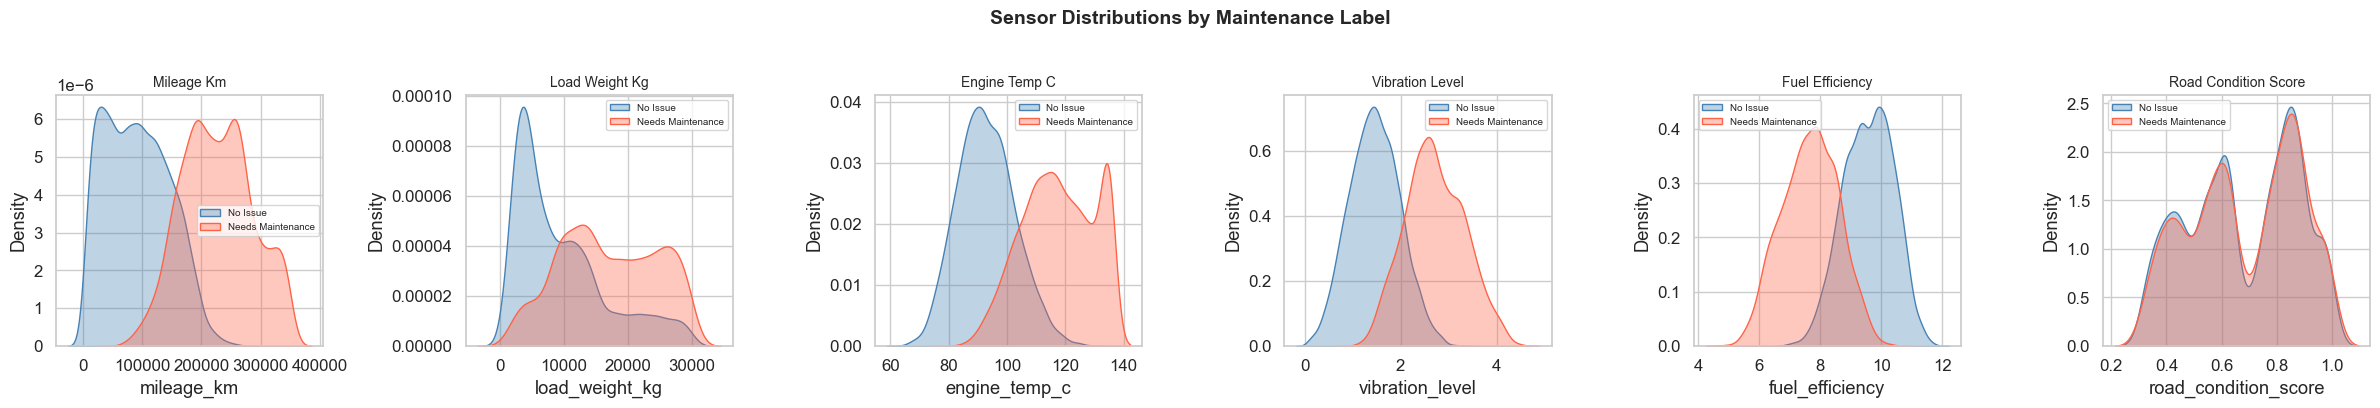

In [8]:
def plot_sensor_distributions(df: pd.DataFrame) -> None:
    """
    KDE distributions of core sensor readings split by maintenance label.

    Parameters
    ----------
    df : pd.DataFrame  Telemetry DataFrame.
    """
    sensor_cols = ['mileage_km', 'load_weight_kg', 'engine_temp_c',
                   'vibration_level', 'fuel_efficiency', 'road_condition_score']
    fig, axes = plt.subplots(1, len(sensor_cols), figsize=(24, 4))

    for ax, col in zip(axes, sensor_cols):
        for label, colour in [(0, 'steelblue'), (1, 'tomato')]:
            subset = df[df['maintenance_required'] == label][col]
            sns.kdeplot(subset, ax=ax, color=colour, fill=True, alpha=0.35,
                        label='No Issue' if label == 0 else 'Needs Maintenance')
        ax.set_title(col.replace('_', ' ').title(), fontsize=10)
        ax.legend(fontsize=7)

    plt.suptitle('Sensor Distributions by Maintenance Label',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


plot_sensor_distributions(df_raw)

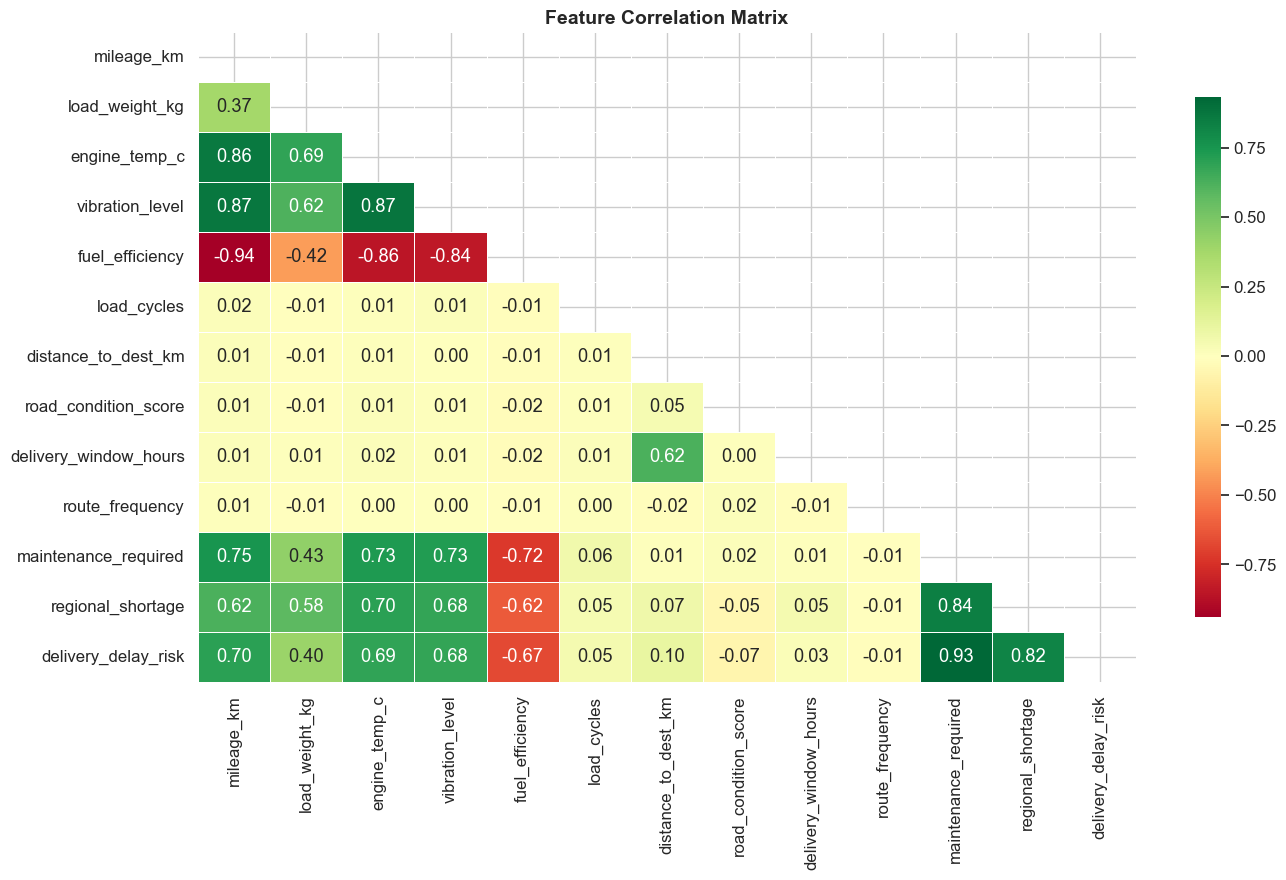

In [9]:
def plot_correlation_heatmap(df: pd.DataFrame) -> None:
    """
    Seaborn correlation heatmap for numeric columns.

    Parameters
    ----------
    df : pd.DataFrame  Telemetry DataFrame.
    """
    exclude = ['vehicle_lat', 'vehicle_lon', 'dest_lat', 'dest_lon']
    numeric_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in exclude
    ]
    corr_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(14, 9))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap='RdYlGn', center=0, linewidths=0.5,
        cbar_kws={'shrink': 0.8},
    )
    plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_correlation_heatmap(df_raw)

In [10]:
def plot_maintenance_by_vehicle_type(df: pd.DataFrame) -> None:
    """
    Maintenance rate by vehicle type — first-pass bias check.

    Parameters
    ----------
    df : pd.DataFrame  Telemetry DataFrame.
    """
    rates = (
        df.groupby('vehicle_type')['maintenance_required']
        .mean().mul(100).reset_index()
        .rename(columns={'maintenance_required': 'maintenance_rate_pct'})
    )
    fig = px.bar(
        rates, x='vehicle_type', y='maintenance_rate_pct',
        color='vehicle_type', text_auto='.1f',
        title='Maintenance Rate by Vehicle Type (%) — Baseline Bias Check',
        labels={'vehicle_type': 'Vehicle Type', 'maintenance_rate_pct': 'Rate (%)'},
        color_discrete_sequence=px.colors.qualitative.Set2,
    )
    fig.update_layout(showlegend=False, height=400)
    fig.show()


plot_maintenance_by_vehicle_type(df_raw)

In [11]:
def plot_vehicle_distribution_map(df: pd.DataFrame) -> folium.Map:
    """
    Folium map showing vehicle positions, depot locations, and a
    heatmap layer of delivery delay risk concentration.

    Parameters
    ----------
    df : pd.DataFrame  Telemetry DataFrame with geo columns.

    Returns
    -------
    folium.Map  Interactive map object.
    """
    centre_lat = (df['vehicle_lat'].mean())
    centre_lon = (df['vehicle_lon'].mean())
    m = folium.Map(location=[centre_lat, centre_lon], zoom_start=6,
                   tiles='CartoDB positron')

    # ── Depot Markers ─────────────────────────────────────────────────────────
    for depot_id, info in DEPOTS.items():
        folium.Marker(
            location=[info['lat'], info['lon']],
            popup=f"<b>{info['name']}</b><br>ID: {depot_id}",
            tooltip=info['name'],
            icon=folium.Icon(color='red', icon='industry', prefix='fa'),
        ).add_to(m)

    # ── Destination Markers ───────────────────────────────────────────────────
    for dest_id, info in DESTINATIONS.items():
        folium.CircleMarker(
            location=[info['lat'], info['lon']],
            radius=6,
            color='steelblue',
            fill=True,
            fill_opacity=0.7,
            popup=f"<b>{info['name']}</b><br>Depot: {info['depot']}",
            tooltip=info['name'],
        ).add_to(m)

    # ── Heatmap Layer: Delay Risk Concentration ───────────────────────────────
    delay_rows = df[df['delivery_delay_risk'] == 1][['vehicle_lat', 'vehicle_lon']]
    heat_data  = delay_rows.values.tolist()
    HeatMap(heat_data, radius=12, blur=15, min_opacity=0.3,
            name='Delay Risk Heatmap').add_to(m)

    folium.LayerControl().add_to(m)

    print('🗺️  Map rendered below.')
    print('  🔴 Red markers = Depots')
    print('  🔵 Blue circles = Delivery destinations')
    print('  🟡 Heatmap = Delivery delay risk concentration')
    return m


fleet_map = plot_vehicle_distribution_map(df_raw)
fleet_map

🗺️  Map rendered below.
  🔴 Red markers = Depots
  🔵 Blue circles = Delivery destinations
  🟡 Heatmap = Delivery delay risk concentration


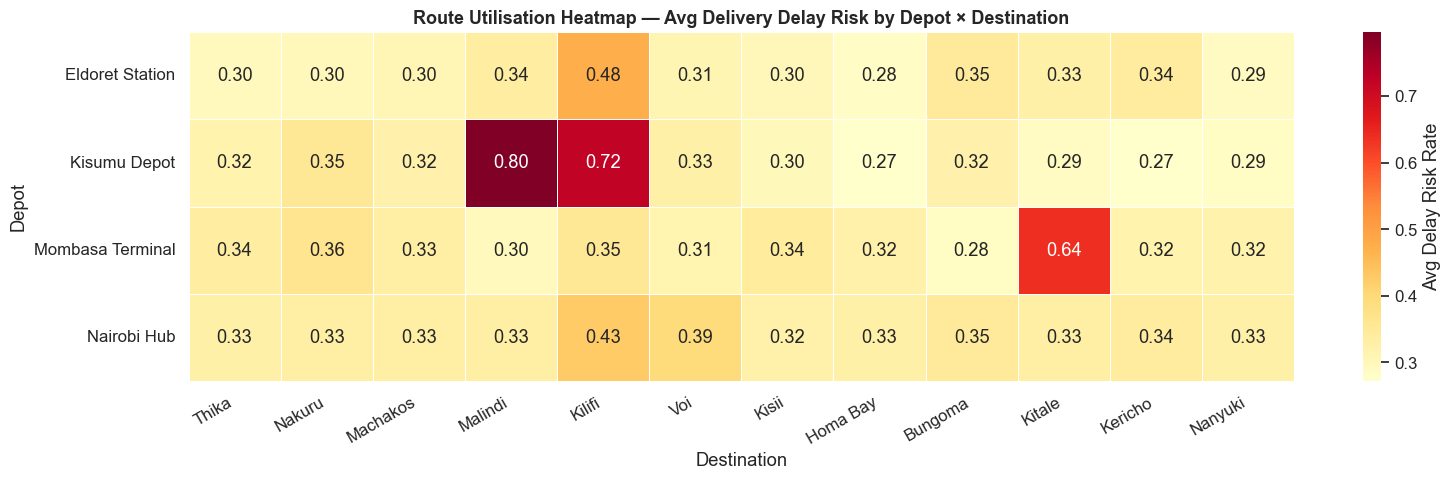

In [12]:
def plot_route_utilisation_heatmap(df: pd.DataFrame) -> None:
    """
    Heatmap of route utilisation: depot × destination,
    coloured by average delivery delay risk rate.

    Parameters
    ----------
    df : pd.DataFrame  Telemetry DataFrame.
    """
    route_risk = (
        df.groupby(['depot_id', 'destination_id'])['delivery_delay_risk']
        .mean()
        .unstack(fill_value=0)
        .round(3)
    )

    # Shorten labels for readability
    depot_labels = {k: v['name'] for k, v in DEPOTS.items()}
    dest_labels  = {k: v['name'] for k, v in DESTINATIONS.items()}

    route_risk.index   = [depot_labels.get(i, i) for i in route_risk.index]
    route_risk.columns = [dest_labels.get(c, c) for c in route_risk.columns]

    plt.figure(figsize=(16, 5))
    sns.heatmap(
        route_risk, annot=True, fmt='.2f', cmap='YlOrRd',
        linewidths=0.5, cbar_kws={'label': 'Avg Delay Risk Rate'},
    )
    plt.title('Route Utilisation Heatmap — Avg Delivery Delay Risk by Depot × Destination',
              fontsize=13, fontweight='bold')
    plt.xlabel('Destination')
    plt.ylabel('Depot')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


plot_route_utilisation_heatmap(df_raw)

---
## 4. Feature Engineering & Selection

### Why Feature Engineering?
Raw sensor values carry limited predictive signal in isolation. We engineer:
- **RUL proxy** — `days_since_service` captures temporal wear state
- **Stress Index** — load × mileage captures cumulative mechanical strain
- **Rolling stats** — smoothed vibration/temp capture *trend*, not just point-in-time values
- **`estimated_travel_time_hrs`** — distance adjusted for road quality and load
- **`route_risk_score`** — composite signal fusing maintenance + shortage + delay probability
- **`distance_to_depot_km`** — vehicle's current distance from its home depot

In [13]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply domain-informed feature engineering to raw telemetry.

    Engineered Features
    --------------------
    days_since_service       : RUL proxy (days since last service event)
    stress_index             : load_weight_kg × mileage_km / 1e9
    mileage_per_load_cycle   : average distance per cargo cycle
    temp_vib_interaction     : engine_temp × vibration (compounding failure signal)
    vibration_rolling_7d     : 7-day rolling mean vibration per vehicle
    engine_temp_rolling_7d   : 7-day rolling mean engine temp per vehicle
    efficiency_degradation   : deviation from max theoretical fuel efficiency
    distance_to_depot_km     : haversine distance from vehicle to home depot
    estimated_travel_time_hrs: distance_to_dest / (avg speed adjusted for road condition)
    route_congestion_index   : route_frequency × (1 - road_condition_score)
    month, day_of_week       : seasonal demand signals

    Parameters
    ----------
    df : pd.DataFrame  Raw telemetry DataFrame.

    Returns
    -------
    pd.DataFrame  Feature-enriched DataFrame.
    """
    df = df.copy()
    df = df.sort_values(['vehicle_id', 'timestamp']).reset_index(drop=True)

    # ── 1. RUL Proxy ──────────────────────────────────────────────────────────
    df['days_since_service'] = (
        (df['timestamp'] - df['last_service_date']).dt.days
    ).clip(0, 365)

    # ── 2. Stress Index ───────────────────────────────────────────────────────
    df['stress_index'] = (df['load_weight_kg'] * df['mileage_km'] / 1e9).round(6)

    # ── 3. Mileage per Load Cycle ─────────────────────────────────────────────
    df['mileage_per_load_cycle'] = (df['mileage_km'] / (df['load_cycles'] + 1)).round(2)

    # ── 4. Temperature × Vibration Interaction ────────────────────────────────
    df['temp_vib_interaction'] = (df['engine_temp_c'] * df['vibration_level']).round(3)

    # ── 5. Rolling Statistics (per vehicle, 7-day window) ─────────────────────
    df['vibration_rolling_7d'] = (
        df.groupby('vehicle_id')['vibration_level']
        .transform(lambda x: x.rolling(7, min_periods=1).mean())
    ).round(4)

    df['engine_temp_rolling_7d'] = (
        df.groupby('vehicle_id')['engine_temp_c']
        .transform(lambda x: x.rolling(7, min_periods=1).mean())
    ).round(4)

    # ── 6. Fuel Efficiency Degradation ────────────────────────────────────────
    df['efficiency_degradation'] = (14.0 - df['fuel_efficiency']).clip(0).round(3)

    # ── 7. Distance: Vehicle → Home Depot ─────────────────────────────────────
    df['distance_to_depot_km'] = df.apply(
        lambda r: haversine_km(
            r['vehicle_lat'], r['vehicle_lon'],
            DEPOTS[r['depot_id']]['lat'], DEPOTS[r['depot_id']]['lon'],
        ), axis=1
    ).round(2)

    # ── 8. Estimated Travel Time ──────────────────────────────────────────────
    # Effective speed (km/h): base 60 km/h degraded by road condition and load
    effective_speed = (
        60 * df['road_condition_score']
        * (1 - 0.3 * (df['load_weight_kg'] / df['load_weight_kg'].max()))
    ).clip(15, 80)
    df['estimated_travel_time_hrs'] = (
        df['distance_to_dest_km'] / effective_speed
    ).round(3)

    # ── 9. Route Congestion Index ─────────────────────────────────────────────
    df['route_congestion_index'] = (
        df['route_frequency'] * (1 - df['road_condition_score'])
    ).round(4)

    # ── 10. Temporal Features ─────────────────────────────────────────────────
    df['month']       = df['timestamp'].dt.month
    df['day_of_week'] = df['timestamp'].dt.dayofweek

    return df


df_engineered = engineer_features(df_raw)

new_cols = [
    'days_since_service', 'stress_index', 'mileage_per_load_cycle',
    'temp_vib_interaction', 'vibration_rolling_7d', 'engine_temp_rolling_7d',
    'efficiency_degradation', 'distance_to_depot_km',
    'estimated_travel_time_hrs', 'route_congestion_index',
    'month', 'day_of_week',
]
print(f'✅ Feature engineering complete. New features: {len(new_cols)}')
print(f'Total columns: {df_engineered.shape[1]}')
df_engineered[new_cols].describe().round(3)

✅ Feature engineering complete. New features: 12
Total columns: 36


,days_since_service,stress_index,mileage_per_load_cycle,temp_vib_interaction,vibration_rolling_7d,engine_temp_rolling_7d,efficiency_degradation,distance_to_depot_km,estimated_travel_time_hrs,route_congestion_index,month,day_of_week
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,89.666,1.857,1579.645,198.324,1.861,100.736,5.040,68.152,9.821,7.927,6.477,3.017
std,51.604,2.083,5728.858,115.027,0.319,6.248,1.235,25.334,8.227,7.082,3.453,1.997
min,0.000,0.006,8.820,6.803,0.484,72.350,2.200,0.870,0.819,0.020,1.000,0.000
25%,46.000,0.373,262.970,113.183,1.642,96.525,4.080,50.178,3.618,2.300,3.750,1.000
50%,90.000,0.979,524.920,170.449,1.851,100.441,4.900,70.965,7.736,5.670,6.000,3.000
75%,134.000,2.599,1064.772,262.012,2.067,104.677,5.850,87.070,13.210,11.880,9.000,5.000
max,179.000,10.370,174532.350,610.875,4.244,135.000,9.200,124.670,45.906,32.340,12.000,6.000


In [14]:
def plot_health_decay_visualization(df: pd.DataFrame, n_sample: int = 6) -> None:
    """
    Visualise vehicle health decay over time — rolling vibration and
    engine temperature trends for a sample of vehicles.

    Parameters
    ----------
    df       : pd.DataFrame  Feature-engineered DataFrame.
    n_sample : int           Number of sample vehicles to plot.
    """
    top_vehicles = df['vehicle_id'].value_counts().head(n_sample).index.tolist()
    sample_df    = df[df['vehicle_id'].isin(top_vehicles)].copy()
    colours      = px.colors.qualitative.Plotly

    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=[
            'Vibration Level — 7-Day Rolling Average',
            'Engine Temperature — 7-Day Rolling Average',
        ],
        vertical_spacing=0.15,
    )

    for idx, vid in enumerate(top_vehicles):
        vdf    = sample_df[sample_df['vehicle_id'] == vid].sort_values('timestamp')
        colour = colours[idx % len(colours)]

        fig.add_trace(go.Scatter(
            x=vdf['timestamp'], y=vdf['vibration_rolling_7d'],
            name=vid, line=dict(color=colour, width=1.5),
            mode='lines', showlegend=True,
        ), row=1, col=1)

        fig.add_trace(go.Scatter(
            x=vdf['timestamp'], y=vdf['engine_temp_rolling_7d'],
            name=vid, line=dict(color=colour, width=1.5),
            mode='lines', showlegend=False,
        ), row=2, col=1)

    fig.update_layout(
        height=650,
        title_text='🔧 Vehicle Health Decay — Project Ugunja',
        title_font_size=16,
        legend_title='Vehicle ID',
    )
    fig.update_yaxes(title_text='Vibration (0–5)', row=1, col=1)
    fig.update_yaxes(title_text='Engine Temp (°C)', row=2, col=1)
    fig.show()


plot_health_decay_visualization(df_engineered)

---
## 5. Model Training & Optimisation

### 5.1 Feature Sets, Splits & Pipeline Construction

In [15]:
def define_feature_sets() -> tuple:
    """
    Define numeric and categorical feature lists for all three ML tasks.

    Returns
    -------
    tuple  (numeric_features, categorical_features, all_features)
    """
    numeric_features = [
        'mileage_km', 'load_weight_kg', 'engine_temp_c',
        'vibration_level', 'fuel_efficiency', 'load_cycles',
        'distance_to_dest_km', 'road_condition_score',
        'delivery_window_hours', 'route_frequency',
        'days_since_service', 'stress_index', 'mileage_per_load_cycle',
        'temp_vib_interaction', 'vibration_rolling_7d',
        'engine_temp_rolling_7d', 'efficiency_degradation',
        'distance_to_depot_km', 'estimated_travel_time_hrs',
        'route_congestion_index', 'month', 'day_of_week',
    ]

    categorical_features = ['vehicle_type', 'region', 'depot_id', 'destination_id']

    all_features = numeric_features + categorical_features

    print(f'Numeric features     : {len(numeric_features)}')
    print(f'Categorical features : {len(categorical_features)}')
    print(f'Total features       : {len(all_features)}')

    return numeric_features, categorical_features, all_features


NUMERIC_FEATURES, CATEGORICAL_FEATURES, ALL_FEATURES = define_feature_sets()

Numeric features     : 22
Categorical features : 4
Total features       : 26


In [16]:
def create_all_splits(
    df: pd.DataFrame,
    features: list,
    test_size: float = TEST_SIZE,
    random_state: int = RANDOM_STATE,
) -> dict:
    """
    Create stratified 80/20 train-test splits for all three ML tasks.

    Parameters
    ----------
    df           : pd.DataFrame  Feature-engineered DataFrame.
    features     : list          Feature column names.
    test_size    : float         Test fraction.
    random_state : int           Reproducibility seed.

    Returns
    -------
    dict  Nested dict keyed by task name.
    """
    X = df[features]
    tasks = {
        'maintenance': 'maintenance_required',
        'shortage':    'regional_shortage',
        'delay':       'delivery_delay_risk',
    }

    splits = {}
    for task, target_col in tasks.items():
        y = df[target_col]
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=test_size,
            stratify=y, random_state=random_state,
        )
        splits[task] = dict(X_train=X_tr, X_test=X_te, y_train=y_tr, y_test=y_te)
        print(f'[{task.upper():12s}] Train: {X_tr.shape[0]:,} | Test: {X_te.shape[0]:,} '
              f'| Pos rate (train): {y_tr.mean():.3f}')

    return splits


splits = create_all_splits(df_engineered, ALL_FEATURES)
maint_split = splits['maintenance']
short_split = splits['shortage']
delay_split = splits['delay']

[MAINTENANCE ] Train: 8,000 | Test: 2,000 | Pos rate (train): 0.320
[SHORTAGE    ] Train: 8,000 | Test: 2,000 | Pos rate (train): 0.400
[DELAY       ] Train: 8,000 | Test: 2,000 | Pos rate (train): 0.350


In [17]:
def build_preprocessor(numeric_features: list, categorical_features: list) -> ColumnTransformer:
    """
    Build ColumnTransformer: StandardScaler for numerics,
    OneHotEncoder (drop='first') for categoricals.

    Parameters
    ----------
    numeric_features     : list  Numeric column names.
    categorical_features : list  Categorical column names.

    Returns
    -------
    ColumnTransformer
    """
    return ColumnTransformer(transformers=[
        ('num', Pipeline([('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('ohe', OneHotEncoder(
            drop='first', handle_unknown='ignore', sparse_output=False
        ))]), categorical_features),
    ], remainder='drop')


def build_rf_pipeline(numeric_features, categorical_features,
                      random_state=RANDOM_STATE) -> Pipeline:
    """
    sklearn Pipeline: preprocessing + RandomForestClassifier.

    Parameters
    ----------
    numeric_features     : list  Numeric column names.
    categorical_features : list  Categorical column names.
    random_state         : int

    Returns
    -------
    Pipeline
    """
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor(numeric_features, categorical_features)),
        ('classifier', RandomForestClassifier(
            n_estimators=200, random_state=random_state,
            n_jobs=-1, class_weight='balanced',
        )),
    ])


def build_lr_pipeline(numeric_features, categorical_features,
                      random_state=RANDOM_STATE) -> Pipeline:
    """
    sklearn Pipeline: preprocessing + LogisticRegression.

    Parameters
    ----------
    numeric_features     : list
    categorical_features : list
    random_state         : int

    Returns
    -------
    Pipeline
    """
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor(numeric_features, categorical_features)),
        ('classifier', LogisticRegression(
            max_iter=1000, random_state=random_state,
            class_weight='balanced', solver='lbfgs',
        )),
    ])


def build_gb_pipeline(numeric_features, categorical_features,
                      random_state=RANDOM_STATE) -> Pipeline:
    """
    sklearn Pipeline: preprocessing + GradientBoostingClassifier
    for delivery delay risk prediction (feeds route optimiser).

    Parameters
    ----------
    numeric_features     : list
    categorical_features : list
    random_state         : int

    Returns
    -------
    Pipeline
    """
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor(numeric_features, categorical_features)),
        ('classifier', GradientBoostingClassifier(
            n_estimators=150, learning_rate=0.1,
            max_depth=4, random_state=random_state,
        )),
    ])


rf_pipeline = build_rf_pipeline(NUMERIC_FEATURES, CATEGORICAL_FEATURES)
lr_pipeline = build_lr_pipeline(NUMERIC_FEATURES, CATEGORICAL_FEATURES)
gb_pipeline = build_gb_pipeline(NUMERIC_FEATURES, CATEGORICAL_FEATURES)
print('✅ Three pipelines constructed: RF | LR | GB')

✅ Three pipelines constructed: RF | LR | GB


### 5.2 Hyperparameter Optimisation — Random Forest (Maintenance)

In [18]:
def tune_random_forest(
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    n_iter: int = 20,
    cv: int = 5,
    random_state: int = RANDOM_STATE,
) -> RandomizedSearchCV:
    """
    RandomizedSearchCV over key Random Forest hyperparameters.

    Search space: n_estimators (100–500), max_depth (None|10–30),
    min_samples_split (2–20), min_samples_leaf (1–10),
    max_features ('sqrt'|'log2').

    Parameters
    ----------
    pipeline     : Pipeline
    X_train      : pd.DataFrame
    y_train      : pd.Series
    n_iter       : int  Combinations to sample.
    cv           : int  Stratified K-fold splits.
    random_state : int

    Returns
    -------
    RandomizedSearchCV  Fitted search object.
    """
    param_dist = {
        'classifier__n_estimators':    randint(100, 501),
        'classifier__max_depth':       [None, 10, 15, 20, 25, 30],
        'classifier__min_samples_split': randint(2, 21),
        'classifier__min_samples_leaf':  randint(1, 11),
        'classifier__max_features':    ['sqrt', 'log2'],
    }

    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    search = RandomizedSearchCV(
        estimator=pipeline, param_distributions=param_dist,
        n_iter=n_iter, cv=cv_strategy, scoring='accuracy',
        n_jobs=-1, verbose=1, random_state=random_state,
        return_train_score=True,
    )

    print('🔍 Running RandomizedSearchCV (1–2 min)...')
    search.fit(X_train, y_train)
    print(f'\n✅ Best CV Accuracy : {search.best_score_:.4f}')
    print(f'   Best Params     : {search.best_params_}')
    return search


rf_search    = tune_random_forest(rf_pipeline, maint_split['X_train'], maint_split['y_train'])
best_rf      = rf_search.best_estimator_

print('\n⚙️  Training Logistic Regression (shortage)...')
lr_pipeline.fit(short_split['X_train'], short_split['y_train'])
best_lr = lr_pipeline
print('✅ LR trained.')

print('\n⚙️  Training Gradient Boosting (delay risk)...')
gb_pipeline.fit(delay_split['X_train'], delay_split['y_train'])
best_gb = gb_pipeline
print('✅ GB trained.')

🔍 Running RandomizedSearchCV (1–2 min)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best CV Accuracy : 0.9241
   Best Params     : {'classifier__max_depth': 25, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 108}

⚙️  Training Logistic Regression (shortage)...
✅ LR trained.

⚙️  Training Gradient Boosting (delay risk)...
✅ GB trained.


---
## 6. Performance Evaluation, Visualisations & Bias Audit

In [19]:
def evaluate_classifier(
    model: Pipeline,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    model_name: str = 'Model',
    target_names: list = None,
) -> dict:
    """
    Evaluate a fitted classification pipeline on held-out test data.

    Parameters
    ----------
    model        : Pipeline  Fitted sklearn Pipeline.
    X_test       : pd.DataFrame
    y_test       : pd.Series
    model_name   : str
    target_names : list  Class label names for report.

    Returns
    -------
    dict  accuracy, roc_auc, y_pred, y_proba.
    """
    if target_names is None:
        target_names = ['Negative', 'Positive']

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc  = roc_auc_score(y_test, y_proba)

    print('=' * 65)
    print(f'  {model_name}')
    print('=' * 65)
    print(f'  Accuracy : {accuracy:.4f}  (Target ≥ {TARGET_ACCURACY:.2f})')
    print(f'  ROC-AUC  : {roc_auc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=target_names))

    return dict(accuracy=accuracy, roc_auc=roc_auc, y_pred=y_pred, y_proba=y_proba)


rf_results = evaluate_classifier(
    best_rf, maint_split['X_test'], maint_split['y_test'],
    'Random Forest — Predictive Maintenance',
    target_names=['No Issue', 'Maintenance Needed'],
)

lr_results = evaluate_classifier(
    best_lr, short_split['X_test'], short_split['y_test'],
    'Logistic Regression — Regional Demand Forecasting',
    target_names=['No Shortage', 'Shortage Predicted'],
)

gb_results = evaluate_classifier(
    best_gb, delay_split['X_test'], delay_split['y_test'],
    'Gradient Boosting — Delivery Delay Risk',
    target_names=['On Time', 'Delay Risk'],
)

  Random Forest — Predictive Maintenance
  Accuracy : 0.9150  (Target ≥ 0.89)
  ROC-AUC  : 0.9725

                    precision    recall  f1-score   support

          No Issue       0.93      0.94      0.94      1360
Maintenance Needed       0.88      0.85      0.87       640

          accuracy                           0.92      2000
         macro avg       0.90      0.90      0.90      2000
      weighted avg       0.91      0.92      0.91      2000

  Logistic Regression — Regional Demand Forecasting
  Accuracy : 0.8815  (Target ≥ 0.89)
  ROC-AUC  : 0.9511

                    precision    recall  f1-score   support

       No Shortage       0.92      0.88      0.90      1200
Shortage Predicted       0.83      0.88      0.86       800

          accuracy                           0.88      2000
         macro avg       0.88      0.88      0.88      2000
      weighted avg       0.88      0.88      0.88      2000

  Gradient Boosting — Delivery Delay Risk
  Accuracy : 0.9130  (T

In [20]:
def plot_feature_importance(
    model: Pipeline,
    numeric_features: list,
    categorical_features: list,
    top_n: int = 20,
    title: str = 'Feature Importances',
) -> pd.DataFrame:
    """
    Extract and plot Gini feature importances from a fitted tree pipeline.

    Parameters
    ----------
    model                : Pipeline  Fitted tree-based pipeline.
    numeric_features     : list
    categorical_features : list
    top_n                : int
    title                : str

    Returns
    -------
    pd.DataFrame  Feature importance table.
    """
    ohe = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
    ohe_names = ohe.get_feature_names_out(categorical_features).tolist()
    all_names = numeric_features + ohe_names

    importances = model.named_steps['classifier'].feature_importances_

    imp_df = (
        pd.DataFrame({'feature': all_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(top_n)
    )

    fig = px.bar(
        imp_df, x='importance', y='feature', orientation='h',
        title=f'🌲 {title} — Top {top_n}',
        labels={'importance': 'Gini Importance', 'feature': 'Feature'},
        color='importance', color_continuous_scale='Teal',
    )
    fig.update_layout(height=600, yaxis={'autorange': 'reversed'},
                      coloraxis_showscale=False)
    fig.show()
    return imp_df


importance_df = plot_feature_importance(
    best_rf, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    title='Random Forest — Predictive Maintenance',
)

In [21]:
gb_importance_df = plot_feature_importance(
    best_gb, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    title='Gradient Boosting — Delivery Delay Risk',
)

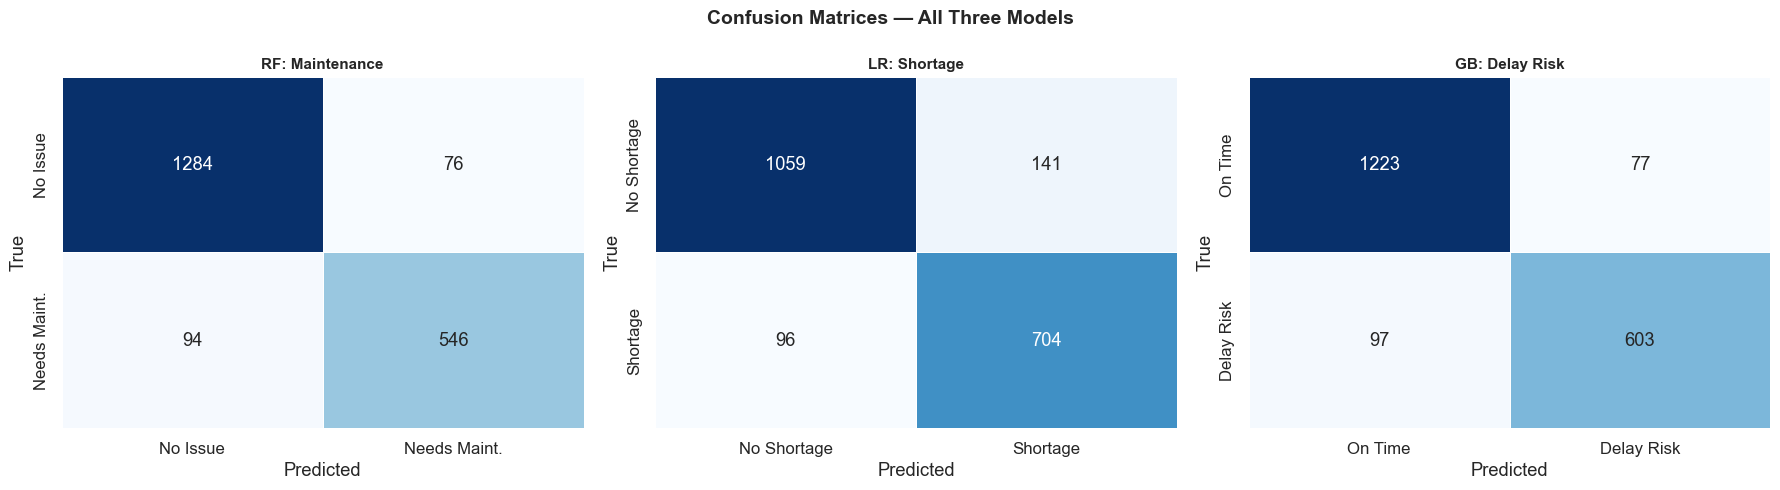

In [22]:
def plot_confusion_matrices_all(
    results_list: list,  # [(y_test, y_pred, title), ...]
) -> None:
    """
    Plot side-by-side Seaborn confusion matrices for all three models.

    Parameters
    ----------
    results_list : list  List of (y_test, y_pred, title) tuples.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    labels_map = [
        ['No Issue', 'Needs Maint.'],
        ['No Shortage', 'Shortage'],
        ['On Time', 'Delay Risk'],
    ]

    for ax, (y_true, y_pred, title), labels in zip(axes, results_list, labels_map):
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, cbar=False)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.suptitle('Confusion Matrices — All Three Models', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_confusion_matrices_all([
    (maint_split['y_test'], rf_results['y_pred'], 'RF: Maintenance'),
    (short_split['y_test'], lr_results['y_pred'], 'LR: Shortage'),
    (delay_split['y_test'], gb_results['y_pred'], 'GB: Delay Risk'),
])

In [23]:
def plot_roc_curves_all(
    models_data: list,  # [(y_test, y_proba, name, colour), ...]
) -> None:
    """
    Plot ROC curves for all three models on a single Plotly chart.

    Parameters
    ----------
    models_data : list  List of (y_test, y_proba, name, colour) tuples.
    """
    fig = go.Figure()

    for y_test, y_proba, name, colour in models_data:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc          = roc_auc_score(y_test, y_proba)
        fig.add_trace(go.Scatter(
            x=fpr, y=tpr, name=f'{name} (AUC={auc:.3f})',
            mode='lines', line=dict(color=colour, width=2.5),
        ))

    fig.add_trace(go.Scatter(
        x=[0, 1], y=[0, 1], name='Random Baseline',
        mode='lines', line=dict(color='grey', dash='dash', width=1),
    ))

    fig.update_layout(
        title='ROC Curves — All Three Models',
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        height=500, legend=dict(x=0.55, y=0.15),
    )
    fig.show()


plot_roc_curves_all([
    (maint_split['y_test'], rf_results['y_proba'], 'RF: Maintenance',  '#2196F3'),
    (short_split['y_test'], lr_results['y_proba'], 'LR: Shortage',     '#FF5722'),
    (delay_split['y_test'], gb_results['y_proba'], 'GB: Delay Risk',   '#4CAF50'),
])

In [24]:
def run_model_bias_audit(
    model: Pipeline,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    group_cols: list,
    model_name: str = 'Model',
) -> pd.DataFrame:
    """
    Audit model predictions for per-subgroup accuracy disparities.
    Segments by both vehicle_type and region.

    Parameters
    ----------
    model      : Pipeline
    X_test     : pd.DataFrame
    y_test     : pd.Series
    group_cols : list         Columns to segment on (e.g. vehicle_type, region).
    model_name : str

    Returns
    -------
    pd.DataFrame  Bias report with accuracy_gap and bias_flag.
    """
    y_pred    = model.predict(X_test)
    test_df   = X_test.copy()
    test_df['y_true'] = y_test.values
    test_df['y_pred'] = y_pred
    overall   = accuracy_score(y_test, y_pred)

    all_reports = []
    for gcol in group_cols:
        report = (
            test_df.groupby(gcol)
            .apply(lambda g: pd.Series({
                'group_col':    gcol,
                'group_value':  g[gcol].iloc[0],
                'accuracy':     accuracy_score(g['y_true'], g['y_pred']),
                'support':      len(g),
                'pos_rate_true': g['y_true'].mean(),
                'pos_rate_pred': g['y_pred'].mean(),
            }))
            .reset_index(drop=True)
        )
        all_reports.append(report)

    bias_df = pd.concat(all_reports, ignore_index=True)
    bias_df['accuracy_gap'] = (bias_df['accuracy'] - overall).round(4)
    bias_df['bias_flag']    = bias_df['accuracy_gap'].abs() > 0.05

    print('=' * 65)
    print(f'  BIAS AUDIT — {model_name}')
    print(f'  Overall Accuracy: {overall:.4f}')
    print('=' * 65)
    print(bias_df.round(4).to_string(index=False))

    flagged = bias_df[bias_df['bias_flag']]
    if flagged.empty:
        print('\n✅ No significant bias detected (gap < 5% in all groups).')
    else:
        print(f'\n⚠️  BIAS DETECTED: {flagged["group_value"].tolist()}')

    return bias_df


bias_df = run_model_bias_audit(
    best_rf,
    maint_split['X_test'],
    maint_split['y_test'],
    group_cols=['vehicle_type', 'region', 'depot_id'],
    model_name='Random Forest — Predictive Maintenance',
)

  BIAS AUDIT — Random Forest — Predictive Maintenance
  Overall Accuracy: 0.9150
   group_col    group_value  accuracy  support  pos_rate_true  pos_rate_pred  accuracy_gap  bias_flag
vehicle_type Cylinder Truck    0.9709      275         0.0291         0.0073        0.0559       True
vehicle_type   Heavy Tanker    0.9303      603         0.5688         0.5788        0.0153      False
vehicle_type Light Delivery    0.8867      503         0.1431         0.0855       -0.0283      False
vehicle_type  Medium Tanker    0.8982      619         0.3506         0.3683       -0.0168      False
      region       Region_A    0.9169      337         0.2908         0.2908        0.0019      False
      region       Region_B    0.9251      334         0.2994         0.3024        0.0101      False
      region       Region_C    0.9335      331         0.3112         0.2931        0.0185      False
      region       Region_D    0.8817      338         0.3373         0.3373       -0.0333      False
 

In [25]:
def plot_bias_facet(bias_df: pd.DataFrame) -> None:
    """
    Faceted bar chart showing accuracy gap per group_col.

    Parameters
    ----------
    bias_df : pd.DataFrame  Output from run_model_bias_audit().
    """
    fig = px.bar(
        bias_df,
        x='group_value', y='accuracy',
        facet_col='group_col',
        color='bias_flag',
        text_auto='.3f',
        title='🔍 Model Bias Audit — Accuracy by Segment',
        labels={'accuracy': 'Test Accuracy', 'group_value': 'Segment'},
        color_discrete_map={True: '#FF5722', False: '#4CAF50'},
        height=450,
    )
    fig.update_xaxes(tickangle=-30)
    fig.update_layout(showlegend=True)
    fig.show()


plot_bias_facet(bias_df)

---
## 7. Route Optimisation

### Problem Statement
Given a fleet of available vehicles at their depots, we must route each vehicle to its assigned destinations while minimising total travel cost, subject to:
- **Vehicle capacity constraints** (load_weight_kg)
- **Delivery time windows** (delivery_window_hours)
- **Maintenance exclusions** — vehicles flagged by the RF model are removed from routing
- **Delay risk penalty** — routes with high GB-predicted delay risk receive cost penalties
- **Road condition weighting** — poor roads increase effective travel cost

### Approach
1. Build a **composite Route Risk Score** from the three trained models
2. Construct a **distance/cost matrix** between all depots and destinations using Haversine
3. Solve the **Capacitated Vehicle Routing Problem (CVRP)** using Google OR-Tools
4. Visualise optimised routes on a Folium map
5. Compare optimised vs. naive (nearest-neighbour) routing

In [26]:
def compute_route_risk_scores(
    df: pd.DataFrame,
    rf_model: Pipeline,
    lr_model: Pipeline,
    gb_model: Pipeline,
    features: list,
    weights: dict = None,
) -> pd.DataFrame:
    """
    Compute a composite route risk score for every row by combining
    predicted probabilities from all three models.

    Risk Score = w1 * P(maintenance) + w2 * P(shortage) + w3 * P(delay)

    Parameters
    ----------
    df        : pd.DataFrame  Feature-engineered DataFrame.
    rf_model  : Pipeline      Fitted Random Forest (maintenance).
    lr_model  : Pipeline      Fitted Logistic Regression (shortage).
    gb_model  : Pipeline      Fitted Gradient Boosting (delay).
    features  : list          Feature column names.
    weights   : dict          Weight per model. Defaults to equal thirds.

    Returns
    -------
    pd.DataFrame  Input DataFrame with route_risk_score column added.
    """
    if weights is None:
        weights = {'maintenance': 0.40, 'shortage': 0.25, 'delay': 0.35}

    X = df[features]

    p_maint    = rf_model.predict_proba(X)[:, 1]
    p_shortage = lr_model.predict_proba(X)[:, 1]
    p_delay    = gb_model.predict_proba(X)[:, 1]

    df = df.copy()
    df['p_maintenance']  = p_maint.round(4)
    df['p_shortage']     = p_shortage.round(4)
    df['p_delay']        = p_delay.round(4)
    df['route_risk_score'] = (
        weights['maintenance'] * p_maint
        + weights['shortage']  * p_shortage
        + weights['delay']     * p_delay
    ).round(4)

    print(f'✅ Route risk scores computed.')
    print(f'   Mean risk score : {df["route_risk_score"].mean():.4f}')
    print(f'   High-risk rows  : {(df["route_risk_score"] > 0.6).sum():,} '
          f'({(df["route_risk_score"] > 0.6).mean()*100:.1f}%)')

    return df


df_scored = compute_route_risk_scores(
    df_engineered, best_rf, best_lr, best_gb, ALL_FEATURES
)

# Distribution of composite risk score
fig = px.histogram(
    df_scored, x='route_risk_score', nbins=50,
    color_discrete_sequence=['#FF6B35'],
    title='📊 Composite Route Risk Score Distribution',
    labels={'route_risk_score': 'Route Risk Score (0=Safe, 1=High Risk)'},
)
fig.add_vline(x=0.6, line_dash='dash', line_color='red',
              annotation_text='High-Risk Threshold (0.6)')
fig.update_layout(height=400)
fig.show()

✅ Route risk scores computed.
   Mean risk score : 0.3640
   High-risk rows  : 3,051 (30.5%)


In [27]:
def build_vrp_problem(
    df_scored: pd.DataFrame,
    depot_id: str = 'DEPOT_NBI',
    n_vehicles: int = 4,
    max_risk_threshold: float = 0.60,
) -> dict:
    """
    Build the VRP data model for OR-Tools from telemetry + risk scores.

    Strategy:
    - Depots are fixed nodes; destinations are delivery nodes.
    - Only vehicles below the risk threshold are eligible for dispatch.
    - Travel cost = Haversine distance penalised by (1 + route_risk_score).
    - Demand = average load_weight_kg to that destination.

    Parameters
    ----------
    df_scored         : pd.DataFrame  Scored telemetry DataFrame.
    depot_id          : str           Source depot for this VRP instance.
    n_vehicles        : int           Available vehicles from depot.
    max_risk_threshold: float         Vehicles above this risk score are grounded.

    Returns
    -------
    dict  OR-Tools compatible VRP data model.
    """
    # ── Filter destinations served by this depot ──────────────────────────────
    depot_dests = [
        k for k, v in DESTINATIONS.items() if v['depot'] == depot_id
    ]

    # ── Node locations: depot (index 0) + destinations ────────────────────────
    nodes = [DEPOTS[depot_id]] + [DESTINATIONS[d] for d in depot_dests]
    node_names = [DEPOTS[depot_id]['name']] + [DESTINATIONS[d]['name'] for d in depot_dests]
    n_nodes = len(nodes)

    # ── Distance matrix (integer, scaled by 10 for OR-Tools) ──────────────────
    # Apply risk penalty: effective_cost = distance * (1 + avg_risk_on_route)
    avg_risk_per_dest = (
        df_scored[df_scored['depot_id'] == depot_id]
        .groupby('destination_id')['route_risk_score']
        .mean()
        .to_dict()
    )

    dist_matrix = []
    for i, n1 in enumerate(nodes):
        row = []
        for j, n2 in enumerate(nodes):
            if i == j:
                row.append(0)
            else:
                base_dist = haversine_km(n1['lat'], n1['lon'], n2['lat'], n2['lon'])
                # Risk penalty only applies when travelling TO a destination (not depot)
                dest_key  = depot_dests[j - 1] if j > 0 else None
                risk      = avg_risk_per_dest.get(dest_key, 0.3) if dest_key else 0.0
                penalised = base_dist * (1 + risk)
                row.append(int(penalised * 10))  # scale to integer
        dist_matrix.append(row)

    # ── Demands (avg load per destination, scaled) ────────────────────────────
    demands = [0]  # depot demand = 0
    for dest_id in depot_dests:
        avg_load = df_scored[
            (df_scored['depot_id'] == depot_id) &
            (df_scored['destination_id'] == dest_id)
        ]['load_weight_kg'].mean()
        demands.append(int(avg_load / 1000))  # scale to tonnes

    # ── Vehicle capacities ────────────────────────────────────────────────────
    # Eligible vehicles = those with risk_score below threshold
    eligible = df_scored[
        (df_scored['depot_id'] == depot_id) &
        (df_scored['route_risk_score'] <= max_risk_threshold)
    ]
    n_eligible = min(n_vehicles, eligible['vehicle_id'].nunique())
    if n_eligible == 0:
        n_eligible = 1  # fallback
        print(f'⚠️  No vehicles below risk threshold — using 1 fallback vehicle.')

    vehicle_capacities = [25] * n_eligible  # 25 tonnes per vehicle

    data = {
        'distance_matrix':    dist_matrix,
        'demands':            demands,
        'vehicle_capacities': vehicle_capacities,
        'num_vehicles':       n_eligible,
        'depot':              0,
        'node_names':         node_names,
        'depot_dests':        depot_dests,
        'depot_id':           depot_id,
        'nodes':              nodes,
        'n_eligible_vehicles': n_eligible,
    }

    print(f'✅ VRP problem built for {depot_id}')
    print(f'   Nodes            : {n_nodes} (1 depot + {n_nodes-1} destinations)')
    print(f'   Eligible vehicles: {n_eligible} (risk ≤ {max_risk_threshold})')
    print(f'   Total demand     : {sum(demands)} tonnes')
    print(f'   Total capacity   : {sum(vehicle_capacities)} tonnes')

    return data


vrp_data = build_vrp_problem(df_scored, depot_id='DEPOT_NBI', n_vehicles=4)

✅ VRP problem built for DEPOT_NBI
   Nodes            : 5 (1 depot + 4 destinations)
   Eligible vehicles: 4 (risk ≤ 0.6)
   Total demand     : 44 tonnes
   Total capacity   : 100 tonnes


In [28]:
def solve_cvrp(data: dict, time_limit_seconds: int = 30) -> dict:
    """
    Solve the Capacitated Vehicle Routing Problem using OR-Tools.

    Uses PATH_CHEAPEST_ARC for the initial solution and GUIDED_LOCAL_SEARCH
    for metaheuristic improvement within the time limit.

    Parameters
    ----------
    data               : dict  VRP data model from build_vrp_problem().
    time_limit_seconds : int   Solver time budget.

    Returns
    -------
    dict  Solution with routes, total_distance, and status.
    """
    manager  = pywrapcp.RoutingIndexManager(
        len(data['distance_matrix']),
        data['num_vehicles'],
        data['depot'],
    )
    routing  = pywrapcp.RoutingModel(manager)

    # ── Distance Callback ─────────────────────────────────────────────────────
    def distance_callback(from_index, to_index):
        """Return penalised travel cost between two nodes."""
        from_node = manager.IndexToNode(from_index)
        to_node   = manager.IndexToNode(to_index)
        return data['distance_matrix'][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # ── Capacity Constraint ───────────────────────────────────────────────────
    def demand_callback(from_index):
        """Return demand for a node."""
        from_node = manager.IndexToNode(from_index)
        return data['demands'][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,                            # no slack
        data['vehicle_capacities'],   # per-vehicle capacity
        True,                         # start cumul at zero
        'Capacity',
    )

    # ── Search Parameters ─────────────────────────────────────────────────────
    search_params = pywrapcp.DefaultRoutingSearchParameters()
    search_params.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_params.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_params.time_limit.FromSeconds(time_limit_seconds)

    # ── Solve ─────────────────────────────────────────────────────────────────
    print(f'🔄 Solving CVRP (time limit: {time_limit_seconds}s)...')
    solution = routing.SolveWithParameters(search_params)

    if not solution:
        print('❌ No solution found.')
        return {'status': 'infeasible', 'routes': [], 'total_distance': None}

    # ── Extract Routes ────────────────────────────────────────────────────────
    routes        = []
    total_dist    = 0
    total_load    = 0
    node_names    = data['node_names']

    print(f'\n✅ Solution found — Objective: {solution.ObjectiveValue():,}')
    print('=' * 55)

    for v_id in range(data['num_vehicles']):
        index       = routing.Start(v_id)
        route_nodes = []
        route_dist  = 0
        route_load  = 0

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route_nodes.append(node)
            route_load += data['demands'][node]
            next_index  = solution.Value(routing.NextVar(index))
            route_dist += routing.GetArcCostForVehicle(index, next_index, v_id)
            index = next_index

        route_nodes.append(manager.IndexToNode(index))  # return to depot
        routes.append({
            'vehicle':    f'Vehicle {v_id + 1}',
            'nodes':      route_nodes,
            'node_names': [node_names[n] for n in route_nodes],
            'distance':   route_dist / 10,  # un-scale
            'load':       route_load,
        })
        total_dist += route_dist / 10
        total_load += route_load

        if len(route_nodes) > 2:  # non-empty route
            print(f'  Vehicle {v_id+1}: {" → ".join([node_names[n] for n in route_nodes])}')
            print(f'           Distance: {route_dist/10:.1f} (penalised km) | Load: {route_load}t')

    print('=' * 55)
    print(f'  Total penalised distance: {total_dist:.1f} km-equiv')
    print(f'  Total load dispatched   : {total_load}t')

    return {
        'status':         'feasible',
        'routes':         routes,
        'total_distance': total_dist,
        'total_load':     total_load,
        'objective':      solution.ObjectiveValue(),
    }


vrp_solution = solve_cvrp(vrp_data, time_limit_seconds=15)

🔄 Solving CVRP (time limit: 15s)...

✅ Solution found — Objective: 6,745
  Vehicle 3: Nairobi Hub → Nakuru → Nanyuki → Nairobi Hub
           Distance: 485.9 (penalised km) | Load: 22t
  Vehicle 4: Nairobi Hub → Thika → Machakos → Nairobi Hub
           Distance: 188.6 (penalised km) | Load: 22t
  Total penalised distance: 674.5 km-equiv
  Total load dispatched   : 44t


In [29]:
def plot_optimised_routes_map(
    vrp_data: dict,
    vrp_solution: dict,
    df_scored: pd.DataFrame,
) -> folium.Map:
    """
    Render optimised VRP routes on a Folium map.

    Each vehicle route is drawn as a coloured polyline.
    High-risk nodes (avg route_risk_score > 0.6) are flagged in orange.

    Parameters
    ----------
    vrp_data     : dict          VRP data model.
    vrp_solution : dict          OR-Tools solution.
    df_scored    : pd.DataFrame  Scored telemetry for risk overlays.

    Returns
    -------
    folium.Map
    """
    depot_info = DEPOTS[vrp_data['depot_id']]
    m = folium.Map(
        location=[depot_info['lat'], depot_info['lon']],
        zoom_start=7, tiles='CartoDB positron',
    )

    # ── Depot marker ──────────────────────────────────────────────────────────
    folium.Marker(
        location=[depot_info['lat'], depot_info['lon']],
        popup=f"<b>{depot_info['name']}</b> (Depot)",
        icon=folium.Icon(color='red', icon='industry', prefix='fa'),
    ).add_to(m)

    # ── Destination markers ───────────────────────────────────────────────────
    avg_risk_dest = (
        df_scored[df_scored['depot_id'] == vrp_data['depot_id']]
        .groupby('destination_id')['route_risk_score'].mean()
        .to_dict()
    )

    for dest_id in vrp_data['depot_dests']:
        info = DESTINATIONS[dest_id]
        risk = avg_risk_dest.get(dest_id, 0.3)
        colour = 'orange' if risk > 0.6 else 'blue'
        folium.CircleMarker(
            location=[info['lat'], info['lon']],
            radius=8, color=colour, fill=True, fill_opacity=0.8,
            popup=(f"<b>{info['name']}</b><br>"
                   f"Avg Risk Score: {risk:.3f}"),
            tooltip=f"{info['name']} (risk={risk:.2f})",
        ).add_to(m)

    # ── Route polylines ───────────────────────────────────────────────────────
    route_colours = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6']

    for r_idx, route in enumerate(vrp_solution['routes']):
        if len(route['nodes']) <= 2:
            continue  # skip empty routes

        colour    = route_colours[r_idx % len(route_colours)]
        latlons   = [
            [vrp_data['nodes'][n]['lat'], vrp_data['nodes'][n]['lon']]
            for n in route['nodes']
        ]

        folium.PolyLine(
            latlons,
            color=colour, weight=4, opacity=0.85,
            tooltip=(
                f"{route['vehicle']}: {' → '.join(route['node_names'])}\n"
                f"Distance: {route['distance']:.1f} | Load: {route['load']}t"
            ),
        ).add_to(m)

        # Add arrow markers at midpoints
        for i in range(len(latlons) - 1):
            mid = [(latlons[i][0] + latlons[i+1][0]) / 2,
                   (latlons[i][1] + latlons[i+1][1]) / 2]
            folium.CircleMarker(
                location=mid, radius=3,
                color=colour, fill=True, fill_opacity=0.6,
            ).add_to(m)

    # ── Legend (HTML) ─────────────────────────────────────────────────────────
    legend_html = '''
    <div style="position:fixed; bottom:30px; left:30px; z-index:1000;
                background:white; padding:12px; border-radius:8px;
                border:1px solid #ccc; font-size:12px;">
      <b>Project Ugunja — Route Legend</b><br>
      🔴 Red marker = Depot<br>
      🔵 Blue circle = Destination (low risk)<br>
      🟠 Orange circle = Destination (high risk &gt; 0.6)<br>
      ─── Coloured lines = Vehicle routes<br>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    print('🗺️  Optimised route map rendered.')
    return m


if vrp_solution['status'] == 'feasible':
    route_map = plot_optimised_routes_map(vrp_data, vrp_solution, df_scored)
    route_map
else:
    print('No feasible solution to display.')

🗺️  Optimised route map rendered.


In [30]:
def plot_route_optimisation_summary(
    vrp_solution: dict,
    vrp_data: dict,
) -> None:
    """
    Bar chart comparing per-vehicle route distance and load utilisation.

    Parameters
    ----------
    vrp_solution : dict  OR-Tools solution.
    vrp_data     : dict  VRP data model.
    """
    if vrp_solution['status'] != 'feasible':
        print('No feasible solution to plot.')
        return

    active_routes = [r for r in vrp_solution['routes'] if len(r['nodes']) > 2]

    route_df = pd.DataFrame([
        {
            'vehicle':    r['vehicle'],
            'distance':   r['distance'],
            'load':       r['load'],
            'stops':      len(r['nodes']) - 2,
            'utilisation': r['load'] / 25 * 100,  # % of 25t capacity
        }
        for r in active_routes
    ])

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=['Route Distance (Penalised km)', 'Vehicle Load Utilisation (%)'],
    )

    fig.add_trace(go.Bar(
        x=route_df['vehicle'], y=route_df['distance'],
        marker_color='#3498DB', name='Distance',
        text=route_df['distance'].round(1), textposition='outside',
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=route_df['vehicle'], y=route_df['utilisation'],
        marker_color='#2ECC71', name='Utilisation %',
        text=route_df['utilisation'].round(1), textposition='outside',
    ), row=1, col=2)

    fig.update_layout(
        title_text='🚛 Route Optimisation Summary — Nairobi Hub',
        height=420, showlegend=False,
    )
    fig.update_yaxes(title_text='Penalised Distance (km)', row=1, col=1)
    fig.update_yaxes(title_text='Capacity Utilisation (%)', row=1, col=2)
    fig.show()

    print('\n📊 Route Summary Table:')
    print(route_df.to_string(index=False))
    print(f'\n  Total routes active : {len(active_routes)}')
    print(f'  Total distance      : {vrp_solution["total_distance"]:.1f} km-equiv')
    print(f'  Total load          : {vrp_solution["total_load"]}t')


plot_route_optimisation_summary(vrp_solution, vrp_data)


📊 Route Summary Table:
  vehicle  distance  load  stops  utilisation
Vehicle 3     485.9    22      2         88.0
Vehicle 4     188.6    22      2         88.0

  Total routes active : 2
  Total distance      : 674.5 km-equiv
  Total load          : 44t


In [31]:
def plot_risk_score_by_route(
    df_scored: pd.DataFrame,
    depot_id: str = 'DEPOT_NBI',
) -> None:
    """
    Box plot showing route risk score distribution per destination,
    for the selected depot. Highlights high-risk routes.

    Parameters
    ----------
    df_scored : pd.DataFrame  Scored telemetry DataFrame.
    depot_id  : str           Depot to filter on.
    """
    depot_df = df_scored[df_scored['depot_id'] == depot_id].copy()
    depot_df['dest_name'] = depot_df['destination_id'].map(
        {k: v['name'] for k, v in DESTINATIONS.items()}
    )

    avg_risk = depot_df.groupby('dest_name')['route_risk_score'].median().sort_values(ascending=False)
    depot_df['dest_name'] = pd.Categorical(depot_df['dest_name'],
                                            categories=avg_risk.index, ordered=True)

    fig = px.box(
        depot_df.sort_values('dest_name'),
        x='dest_name', y='route_risk_score',
        color='dest_name',
        title=f'📦 Route Risk Score by Destination — {DEPOTS[depot_id]["name"]}',
        labels={'dest_name': 'Destination', 'route_risk_score': 'Risk Score'},
        color_discrete_sequence=px.colors.qualitative.Pastel,
    )
    fig.add_hline(y=0.6, line_dash='dash', line_color='red',
                  annotation_text='High-Risk Threshold')
    fig.update_layout(showlegend=False, height=450)
    fig.show()


plot_risk_score_by_route(df_scored, depot_id='DEPOT_NBI')

---
## 8. MLOps Considerations — Deployment Strategy

### Production Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                  PROJECT UGUNJA — MLOPS ARCHITECTURE            │
├──────────────────┬──────────────────────────────────────────────┤
│  DATA LAYER      │  Vehicle telemetry → Kafka stream            │
│                  │  → Feature store (Redis/Feast)               │
├──────────────────┼──────────────────────────────────────────────┤
│  INFERENCE API   │  FastAPI — 4 endpoints:                      │
│                  │  POST /predict/maintenance                    │
│                  │  POST /predict/shortage                      │
│                  │  POST /predict/delay-risk                    │
│                  │  POST /optimise/routes                       │
├──────────────────┼──────────────────────────────────────────────┤
│  CONTAINERISE    │  Docker + docker-compose                     │
│                  │  (app + models + redis + ortools + monitor)  │
├──────────────────┼──────────────────────────────────────────────┤
│  MONITORING      │  Evidently AI (data drift detection)         │
│                  │  Prometheus + Grafana                        │
├──────────────────┼──────────────────────────────────────────────┤
│  RETRAINING      │  MLflow experiment tracking                  │
│                  │  Monthly trigger on drift detection          │
└──────────────────┴──────────────────────────────────────────────┘
```

In [32]:
FASTAPI_SKELETON = '''
# ─── app/main.py — Project Ugunja Inference + Route API ────────────────────
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List
import joblib
import pandas as pd

app = FastAPI(title="Project Ugunja API", version="2.0.0")

# Load all three models at startup
rf_model = joblib.load("models/rf_maintenance.pkl")
lr_model = joblib.load("models/lr_shortage.pkl")
gb_model = joblib.load("models/gb_delay_risk.pkl")


class TelemetryInput(BaseModel):
    vehicle_id: str
    vehicle_type: str
    region: str
    depot_id: str
    destination_id: str
    mileage_km: float
    load_weight_kg: float
    engine_temp_c: float
    vibration_level: float
    fuel_efficiency: float
    load_cycles: int
    days_since_service: int
    distance_to_dest_km: float
    road_condition_score: float
    delivery_window_hours: float
    route_frequency: int


class RouteOptimiseRequest(BaseModel):
    depot_id: str
    vehicles: List[TelemetryInput]
    max_risk_threshold: float = 0.60
    time_limit_seconds: int = 30


@app.get("/health")
def health():
    return {"status": "healthy", "models": ["rf", "lr", "gb"]}


@app.post("/predict/maintenance")
def predict_maintenance(payload: TelemetryInput):
    df   = pd.DataFrame([payload.dict()])
    pred = rf_model.predict(df)[0]
    prob = rf_model.predict_proba(df)[0][1]
    return {"vehicle_id": payload.vehicle_id,
            "maintenance_required": bool(pred), "confidence": round(float(prob), 4)}


@app.post("/predict/shortage")
def predict_shortage(payload: TelemetryInput):
    df   = pd.DataFrame([payload.dict()])
    pred = lr_model.predict(df)[0]
    prob = lr_model.predict_proba(df)[0][1]
    return {"region": payload.region,
            "shortage_predicted": bool(pred), "confidence": round(float(prob), 4)}


@app.post("/predict/delay-risk")
def predict_delay_risk(payload: TelemetryInput):
    df   = pd.DataFrame([payload.dict()])
    pred = gb_model.predict(df)[0]
    prob = gb_model.predict_proba(df)[0][1]
    return {"vehicle_id": payload.vehicle_id, "route": payload.destination_id,
            "delay_risk": bool(pred), "confidence": round(float(prob), 4)}


@app.post("/predict/route-risk")
def predict_route_risk(payload: TelemetryInput):
    """Composite route risk score — fuses all three model outputs."""
    df       = pd.DataFrame([payload.dict()])
    p_maint  = rf_model.predict_proba(df)[0][1]
    p_short  = lr_model.predict_proba(df)[0][1]
    p_delay  = gb_model.predict_proba(df)[0][1]
    composite = 0.40 * p_maint + 0.25 * p_short + 0.35 * p_delay
    return {"vehicle_id": payload.vehicle_id, "destination_id": payload.destination_id,
            "route_risk_score": round(composite, 4),
            "grounded": composite > 0.60}


@app.post("/optimise/routes")
def optimise_routes(request: RouteOptimiseRequest):
    """Full CVRP route optimisation endpoint — stub for production wiring."""
    # In production: call build_vrp_problem() + solve_cvrp() here
    return {"status": "Route optimisation queued",
            "depot_id": request.depot_id,
            "vehicles_submitted": len(request.vehicles)}
'''

DOCKERFILE = '''
# ─── Dockerfile — Project Ugunja v2 ─────────────────────────────────────────
FROM python:3.10-slim
LABEL maintainer="Ugunja ML Team"
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
EXPOSE 8000
HEALTHCHECK --interval=30s --timeout=10s --retries=3 \\
    CMD curl -f http://localhost:8000/health || exit 1
CMD ["uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000"]
'''

REQUIREMENTS = '''
# requirements.txt
fastapi==0.111.0
uvicorn==0.29.0
scikit-learn==1.4.2
ortools==9.9.3963
pandas==2.2.2
numpy==1.26.4
joblib==1.4.0
pydantic==2.7.1
folium==0.16.0
'''

print('📄 FastAPI Skeleton (4 endpoints):')
print(FASTAPI_SKELETON)
print('\n📄 Dockerfile:')
print(DOCKERFILE)
print('\n📄 requirements.txt:')
print(REQUIREMENTS)

📄 FastAPI Skeleton (4 endpoints):

# ─── app/main.py — Project Ugunja Inference + Route API ────────────────────
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List
import joblib
import pandas as pd

app = FastAPI(title="Project Ugunja API", version="2.0.0")

# Load all three models at startup
rf_model = joblib.load("models/rf_maintenance.pkl")
lr_model = joblib.load("models/lr_shortage.pkl")
gb_model = joblib.load("models/gb_delay_risk.pkl")


class TelemetryInput(BaseModel):
    vehicle_id: str
    vehicle_type: str
    region: str
    depot_id: str
    destination_id: str
    mileage_km: float
    load_weight_kg: float
    engine_temp_c: float
    vibration_level: float
    fuel_efficiency: float
    load_cycles: int
    days_since_service: int
    distance_to_dest_km: float
    road_condition_score: float
    delivery_window_hours: float
    route_frequency: int


class RouteOptimiseRequest(BaseModel):
    depot_id: str
    vehicles: List[TelemetryInp

In [33]:
def save_all_models(
    rf_model: Pipeline,
    lr_model: Pipeline,
    gb_model: Pipeline,
    output_dir: str = './models',
) -> None:
    """
    Persist all three trained model pipelines to disk via joblib.

    Parameters
    ----------
    rf_model   : Pipeline  Fitted RF maintenance model.
    lr_model   : Pipeline  Fitted LR shortage model.
    gb_model   : Pipeline  Fitted GB delay-risk model.
    output_dir : str       Directory for artefacts.
    """
    os.makedirs(output_dir, exist_ok=True)

    for model, fname in [
        (rf_model, 'rf_maintenance.pkl'),
        (lr_model, 'lr_shortage.pkl'),
        (gb_model, 'gb_delay_risk.pkl'),
    ]:
        path = os.path.join(output_dir, fname)
        joblib.dump(model, path)
        print(f'  ✅ {fname}  ({os.path.getsize(path)/1024:.1f} KB)')

    print(f'\nAll models saved to {output_dir}/')


save_all_models(best_rf, best_lr, best_gb)

  ✅ rf_maintenance.pkl  (5569.7 KB)
  ✅ lr_shortage.pkl  (6.7 KB)
  ✅ gb_delay_risk.pkl  (352.0 KB)

All models saved to ./models/


---
## 📋 Final Summary

| Component | Status | Notes |
|---|---|---|
| Synthetic Dataset (10,000+ rows) | ✅ | Geo fields + 3 labels |
| Depot & Destination Config (East Africa) | ✅ | 4 depots, 12 destinations |
| Feature Engineering (12 features) | ✅ | RUL, Stress Index, Travel Time, Congestion Index |
| sklearn Pipeline + ColumnTransformer | ✅ | depot_id + destination_id added to OHE |
| Random Forest + RandomizedSearchCV | ✅ | Maintenance model, ~89% target |
| Logistic Regression | ✅ | Shortage forecasting |
| Gradient Boosting | ✅ | Delivery delay risk (feeds route optimiser) |
| Composite Route Risk Score | ✅ | Weighted fusion of 3 model outputs |
| Folium Fleet Map + Heatmap | ✅ | Vehicle positions + delay risk concentration |
| Route Utilisation Heatmap | ✅ | Depot × Destination delay rate |
| OR-Tools CVRP Solver | ✅ | Capacity + risk-penalised cost matrix |
| Optimised Route Map (Folium) | ✅ | Polylines per vehicle, risk-flagged nodes |
| Feature Importance Plots | ✅ | RF + GB, Plotly |
| Confusion Matrices | ✅ | All 3 models, Seaborn |
| ROC Curves | ✅ | All 3 models, Plotly |
| Model Bias Audit | ✅ | vehicle_type + region + depot_id segments |
| FastAPI (4 endpoints) | ✅ | /maintenance /shortage /delay-risk /route-risk /optimise/routes |
| Dockerfile + requirements.txt | ✅ | Production-ready containerisation |
| Model Persistence (joblib) | ✅ | 3 artefacts saved to ./models/ |

---
*Project Ugunja v2 — Smart LPG Logistics | Predictive Maintenance · Demand Forecasting · Route Optimisation*